<a href="https://colab.research.google.com/github/saifinuha/data-science-2026/blob/main/Pertemuan13_Saifin_Nuha_240401010257.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saifin Nuha, 240401010257, IF403

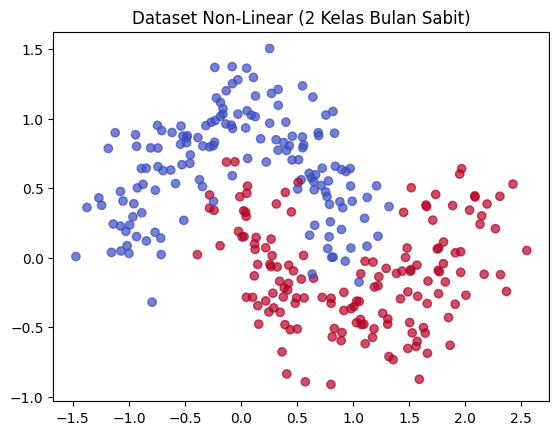

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_tr, X_te, y_tr, y_te = train_test_split(
                            X, y, test_size=0.2, random_state=42)

model = Sequential([
      Dense(16, activation='relu', input_shape=(2,)),
      Dense(8, activation='relu'),
      Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

history = model.fit(X_tr, y_tr, epochs=30,
                    validation_split=0.2, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Akurasi pada data uji: 0.917


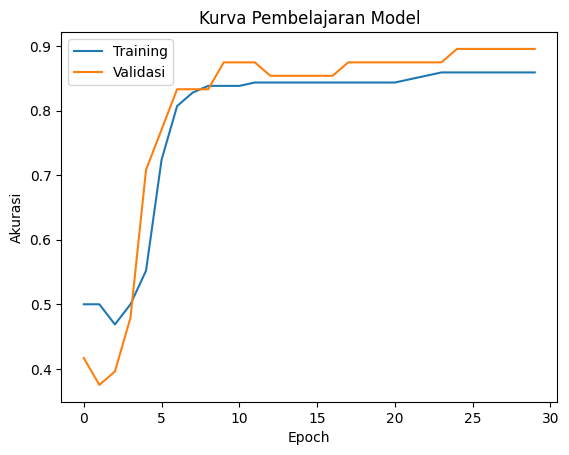

In [3]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()

## Interpretasi Kurva Pembelajaran

Dari "Kurva Pembelajaran Model" yang ditampilkan:

*   **Akurasi Training** dan **Akurasi Validasi** cenderung mengikuti tren yang serupa pada awal pelatihan.
*   Setelah beberapa epoch (sekitar epoch ke-10), kedua kurva menjadi relatif stabil. Akurasi validasi sedikit lebih tinggi dan stabil dibandingkan akurasi training.
*   Kurva akurasi training dan validasi **cukup berdekatan**. Meskipun ada sedikit perbedaan, mereka tidak menunjukkan pemisahan yang signifikan di mana akurasi training terus meningkat tajam sementara akurasi validasi menurun atau stagnan jauh di bawahnya.

**Kesimpulan:** Akurasi training dan validasi **saling mendekat** dan bergerak beriringan setelah mencapai stabilitas. Ini adalah indikasi yang **baik** bahwa model tidak mengalami *overfitting* yang parah pada data pelatihan dan memiliki kemampuan generalisasi yang cukup baik pada data yang belum pernah dilihat sebelumnya (data validasi).

In [4]:
ulasan = [
  'Barangnya bagus banget, pengiriman cepat',
  'Kualitas jelek, tidak sesuai deskripsi',
  'Sangat puas, akan beli lagi',
  'Kecewa, barang rusak saat sampai',
  'Recommended, harga sesuai kualitas',
  'Buruk sekali, tidak sesuai ekspektasi',
  'Respon penjual cepat, barang sesuai gambar',
  'Produk kurang berkualitas, cepat rusak',
  'Packaging rapi, barang aman sampai tujuan',
  'Pengiriman lama sekali, barang tidak datang-datang',
  'Mantap, sesuai ekspektasi, recommended seller',
  'Bahan tipis, tidak nyaman dipakai',
  'Harga murah tapi kualitasnya premium',
  'Saya tidak puas dengan produk ini',
  'Cepat sampai, kondisi barang sempurna',
  'Warna tidak sesuai pesanan, sangat mengecewakan',
  'Pelayanan ramah, produk original',
  'Ukuran tidak pas, terlalu kecil',
  'Top banget, tidak ada cacat sedikitpun',
  'Penipuan, barang palsu',
  'Sangat membantu sekali, terima kasih',
  'Produk cacat, minta retur tidak ditanggapi',
  'Barang berfungsi dengan baik, senang sekali',
  'Ada goresan di produk, kecewa',
  'Melebihi ekspektasi, sangat puas',
  'Tidak akan beli lagi di toko ini',
  'Benar-benar bagus, sesuai harga',
  'Barang imitasi, kualitas rendah',
  'Suka banget sama produknya, recommended',
  'Pengalaman belanja terburuk',
  'Puas sekali, pengiriman super cepat',
  'Tidak sesuai gambar, sangat jelek',
  'Barang oke, sesuai deskripsi',
  'Parah, seller tidak profesional',
  'Packing aman, barang utuh',
  'Barang murahan, menyesal beli',
  'Kualitas terbaik, tidak mengecewakan',
  'Terlambat sampai, janji pengiriman tidak ditepati',
  'Produk sangat inovatif, suka',
  'Rusak total, tidak bisa digunakan',
  'Pengiriman tepat waktu, kurir ramah',
  'Produk sesuai ekspektasi, sangat fungsional',
  'Harga bersaing, kualitas terjamin',
  'Modelnya keren, saya suka sekali',
  'Layanan pelanggan responsif, sangat membantu',
  'Kecewa dengan kualitas catnya, mudah terkelupas',
  'Fungsinya tidak maksimal, tidak berguna',
  'Packing rusak, barang penyok',
  'Reseller tidak jujur, deskripsi palsu',
  'Barang kw, tidak original',
  'Saya sangat merekomendasikan produk ini',
  'Saya tidak akan pernah membeli lagi dari toko ini',
  'Ini adalah pembelian terbaik saya tahun ini',
  'Ulasan ini adalah untuk produk terburuk yang pernah saya beli',
  'Sangat puas dengan pembelian ini, layak untuk setiap sennya',
  'Saya merasa tertipu, produknya sangat mengecewakan'
]
label = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0]

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 142
['ada' 'adalah' 'akan' 'aman' 'bagus' 'bahan' 'baik' 'banget' 'barang'
 'barangnya']


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
X_text, label, test_size=0.2, random_state=42)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.750
Positif


## Penjelasan Labs: Pengantar Deep Learning & NLP Dasar

Labs ini mencakup konsep-konsep dasar dalam Deep Learning dan Natural Language Processing (NLP) dengan fokus pada:

*   **Artificial Neural Network (ANN):**
    *   **Deskripsi:** Penerapan model jaringan saraf tiruan sederhana untuk masalah klasifikasi non-linear. Dalam contoh ini, kita menggunakan model `Sequential` dari TensorFlow/Keras dengan `Dense` layers untuk mengklasifikasikan data bulan sabit.
    *   **Kode:**
        *   Data non-linear (`make_moons`) dibuat dan divisualisasikan (`_Da3JR8VUUm6`).
        *   Data dibagi menjadi set pelatihan dan pengujian menggunakan `train_test_split` (`X9UM1bQrU0m2`).
        *   Model `Sequential` Keras dibangun dengan beberapa layer `Dense` (lapisan terhubung penuh) dan fungsi aktivasi `relu` serta `sigmoid` untuk output biner (`X9UM1bQrU0m2`).
        *   Model dikompilasi dengan optimizer `adam`, fungsi *loss* `binary_crossentropy`, dan metrik `accuracy` (`X9UM1bQrU0m2`).
        *   Model dilatih menggunakan data pelatihan (`X_tr`, `y_tr`) selama 30 *epoch* dengan *validation split* 20% (`X9UM1bQrU0m2`).
        *   Performa model dievaluasi pada data pengujian (`X_te`, `y_te`) dan akurasi dicetak (`5NykbtXEVHNO`).
        *   Kurva pembelajaran (akurasi pelatihan dan validasi) digambarkan untuk memantau performa model sepanjang pelatihan (`5NykbtXEVHNO`).

*   **TF-IDF (Term Frequency-Inverse Document Frequency):**
    *   **Deskripsi:** Sebuah teknik vektorisasi teks yang digunakan untuk mengubah teks mentah (ulasan) menjadi representasi numerik yang dapat dipahami oleh algoritma *machine learning*. TF-IDF memberikan bobot pada kata-kata berdasarkan seberapa sering muncul dalam dokumen dan seberapa unik kata tersebut di seluruh koleksi dokumen.
    *   **Kode:**
        *   Daftar `ulasan` (teks) dan `label` (sentimen: 1 positif, 0 negatif) didefinisikan (`EfkZGrkhVML8`).
        *   Objek `TfidfVectorizer` dari `scikit-learn` diinisialisasi (`d5nbQ5PGVnzY`).
        *   Metode `fit_transform` digunakan untuk mempelajari kosakata dari `ulasan` dan mengubahnya menjadi matriks TF-IDF (`X_text`), serta mencetak jumlah kata unik dan beberapa kata pertama (`d5nbQ5PGVnzY`).

*   **Analisis Sentimen:**
    *   **Deskripsi:** Proses otomatis untuk mengidentifikasi dan mengekstrak opini dari teks. Dalam labs ini, analisis sentimen dilakukan menggunakan model `LogisticRegression` yang dilatih pada fitur TF-IDF dari ulasan produk untuk mengklasifikasikan sentimen sebagai positif (1) atau negatif (0).
    *   **Kode:**
        *   Fitur teks (`X_text`) dan label (`label`) dibagi menjadi set pelatihan dan pengujian (`oj4kxjuRV7Lc`).
        *   Model `LogisticRegression` diinisialisasi dan dilatih menggunakan fitur TF-IDF pelatihan (`Xt_tr`) dan label pelatihan (`yt_tr`) (`oj4kxjuRV7Lc`).
        *   Akurasi model dievaluasi pada data pengujian (`Xt_te`, `yt_te`) dan dicetak (`oj4kxjuRV7Lc`).
        *   Model digunakan untuk memprediksi sentimen dari `kalimat_baru` yang belum pernah dilihat sebelumnya, dan hasilnya dicetak (`oj4kxjuRV7Lc`).